# หาชุดข้อมูลสำหรับ swarm learning บนบล็อกเชน

โน้ตบุ๊กนี้เปิดชุดข้อมูลจริงสามตัวที่เข้ารอบ แล้ววัดคุณสมบัติที่โปรเจกต์นี้ต้องใช้จริง ๆ
ไม่ใช่สรุปจากบทคัดย่อของ paper

**เกณฑ์ที่ใช้ตัดสิน** เรียงตามความสำคัญต่อ `poc/sl-fabric`:

| เกณฑ์ | ทำไมถึงสำคัญกับโปรเจกต์นี้ |
|---|---|
| partition ธรรมชาติ | ถ้าชุดข้อมูลมีเจ้าของจริงติดมาด้วย การอ้างว่า "แต่ละองค์กรถือข้อมูลของตัวเอง" จะไม่ใช่สมมติฐาน และใครรันก็ได้การแบ่งเดียวกันโดยไม่ต้องตกลงวิธีแบ่งกันก่อน |
| มี baseline ที่อ้างได้ | เทียบตัวเลขข้ามงานได้โดยไม่ต้องรันเองทั้งหมด |
| ขนาดพอรันบนเครื่องเดียว | เครือข่าย Fabric 12 container กินแรม ~0.9 GB เหลือให้ไคลเอนต์ราว 6 GB |
| เหตุผลว่าทำไมต้องมีเชน | ผู้ตรวจสอบต้องการหลักฐานย้อนหลัง ไม่ใช่แค่ผลลัพธ์ |

ทุกตัวเลขข้างล่างคำนวณจากไฟล์ที่ดาวน์โหลดมาจริง ยกเว้นส่วนที่กำกับไว้ว่ามาจาก paper

## 0 · เตรียมข้อมูล

ข้อมูลดิบอยู่ใน `data/` ซึ่งถูก gitignore ไว้ ไม่ขึ้น repo คำสั่งโหลดอยู่ในเซลล์ถัดไป
รันครั้งเดียวพอ ถ้ามีไฟล์แล้วเซลล์จะข้ามให้เอง

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# เผื่อกรณีเปิดโน้ตบุ๊กจากที่อื่น: เดินขึ้นไปหาโฟลเดอร์ data/ ที่อยู่ข้าง Explore.ipynb
DATA = next((c for c in (Path("data"), Path("Finding Dataset/data"),
                         Path("poc/Finding Dataset/data"), Path("../data"))
             if c.is_dir()), Path("data"))
NBAIOT = DATA / "nbaiot"
ELLIPTIC = DATA / "elliptic"


def require(path: Path, what: str) -> Path:
    """บอกให้ชัดว่าไฟล์ไหนหาย แทนที่จะปล่อย FileNotFoundError ดิบ ๆ"""
    if not path.exists():
        print(f"ยังไม่มี {what} ที่ {path.resolve()}")
        print("รันคำสั่งดาวน์โหลดในหัวข้อ 0 ก่อน แล้วค่อยรันเซลล์นี้ซ้ำ")
        print("N-BaIoT ใช้เวลาหลายนาที: zip ~1 GB จาก UCI แล้วต้องแตก .rar ต่ออีกชั้น")
        raise SystemExit("ข้อมูลยังไม่ครบ")
    return path

# palette ที่ผ่านการตรวจ colour-blind separation
C = {"blue": "#2a78d6", "orange": "#eb6834", "aqua": "#1baf7a",
     "yellow": "#eda100", "violet": "#4a3aa7", "red": "#e34948",
     "grey": "#8a938f"}

# DejaVu Sans ที่ matplotlib ใช้เป็นค่าตั้งต้นไม่มีอักขระไทย ป้ายกำกับจะกลายเป็นสี่เหลี่ยม
from matplotlib import font_manager
installed = {f.name for f in font_manager.fontManager.ttflist}
THAI_FONT = next((n for n in ("Sarabun", "Thonburi", "Ayuthaya", "Silom") if n in installed), None)
if THAI_FONT is None:
    print("เตือน: ไม่พบฟอนต์ไทยในระบบ ป้ายกำกับในกราฟจะไม่แสดงผล")

plt.rcParams.update({
    "figure.dpi": 120, "font.size": 9, "axes.grid": True,
    "grid.alpha": 0.25, "grid.linewidth": 0.6,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.titlesize": 10, "axes.titleweight": "600",
    "figure.facecolor": "white", "axes.facecolor": "white",
    "font.family": [THAI_FONT] if THAI_FONT else ["DejaVu Sans"],
    "axes.titleweight": "bold",
    "axes.unicode_minus": False,
})
thousands = FuncFormatter(lambda v, _: f"{v:,.0f}")

pd.set_option("display.width", 130)
pd.set_option("display.max_columns", 40)
print("pandas", pd.__version__, "| numpy", np.__version__)

pandas 3.0.5 | numpy 2.5.2


### คำสั่งดาวน์โหลด

```bash
cd "poc/Finding Dataset/data"

# N-BaIoT — UCI ML Repository (zip ~1 GB, แตกแล้วราว 6–7 GB)
curl -L -o nbaiot.zip "https://archive.ics.uci.edu/static/public/442/detection+of+iot+botnet+attacks+n+baiot.zip"
mkdir -p nbaiot && cd nbaiot && unzip -q ../nbaiot.zip

# ไฟล์การโจมตีถูกบีบเป็น .rar อีกชั้นในแต่ละอุปกรณ์
# bsdtar มากับ macOS อยู่แล้วและอ่าน rar ได้ ไม่ต้องลง unrar
for d in */; do (cd "$d" && for r in *.rar; do
  [ -e "$r" ] || continue; mkdir -p "${r%.rar}" && bsdtar -xf "$r" -C "${r%.rar}"
done); done
cd ..

# Elliptic — มิเรอร์บน HuggingFace (รวม ~700 MB)
mkdir -p elliptic && cd elliptic
for f in elliptic_txs_classes elliptic_txs_edgelist elliptic_txs_features; do
  curl -L -o "$f.csv" "https://huggingface.co/datasets/SuodhanJ6/$f/resolve/main/$f.csv"
done
```

---

# 1 · N-BaIoT

9 อุปกรณ์ IoT จริงในบ้าน โดนบอตเน็ต **BASHLITE (gafgyt)** และ **Mirai** จริง
แต่ละอุปกรณ์เป็นโฟลเดอร์ของตัวเอง มีทราฟฟิกปกติหนึ่งไฟล์ และไฟล์การโจมตีแยกตามชนิด
(ในไฟล์ต้นทางการโจมตีถูกบีบเป็น `.rar` อีกชั้น ต้องแตกก่อน ดูคำสั่งในหัวข้อ 0)

สิ่งที่ทำให้ชุดนี้ต่างจาก CIC-IDS2017 หรือ TON_IoT สำหรับงาน federated คือ
**ไม่ต้องสังเคราะห์ partition** เพราะอุปกรณ์แต่ละตัวคือโหนดหนึ่งโหนดอยู่แล้วโดยธรรมชาติ
ทั้งชนิดอุปกรณ์ ปริมาณทราฟฟิก และชนิดการโจมตีที่เจอ ต่างกันจริงตามของจริง

In [2]:
def count_rows(path: Path) -> int:
    """นับแถวโดยไม่ parse ทั้งไฟล์ — N-BaIoT รวมกัน 7 ล้านแถว การ parse ทุกไฟล์เปลืองเวลาเปล่า"""
    with path.open("rb") as fh:
        return max(sum(chunk.count(b"\n") for chunk in iter(lambda: fh.read(1 << 20), b"")) - 1, 0)

require(NBAIOT, "โฟลเดอร์ N-BaIoT ที่แตกไฟล์แล้ว")

records = []
for device_dir in sorted(p for p in NBAIOT.iterdir() if p.is_dir()):
    for csv in sorted(device_dir.rglob("*.csv")):
        rel = csv.relative_to(device_dir)
        if rel.name == "benign_traffic.csv":
            family, attack = "benign", "benign"
        else:
            family = rel.parts[0].split("_")[0]        # gafgyt_attacks / mirai_attacks
            # ทั้งสองตระกูลมี scan และ udp เหมือนกัน ถ้าใช้แค่ชื่อไฟล์คอลัมน์จะถูกยุบรวมกัน
            attack = f"{family}_{rel.stem}"
        records.append({"device": device_dir.name, "family": family,
                        "attack": attack, "rows": count_rows(csv)})

nb = pd.DataFrame(records)
print(f"{nb['device'].nunique()} อุปกรณ์ · {len(nb)} ไฟล์ · {nb['rows'].sum():,} แถวรวม")
nb.head(8)

9 อุปกรณ์ · 89 ไฟล์ · 7,062,606 แถวรวม


,device,family,attack,rows
0,Danmini_Doorbell,benign,benign,49548
1,Danmini_Doorbell,gafgyt,gafgyt_combo,59718
2,Danmini_Doorbell,gafgyt,gafgyt_junk,29068
3,Danmini_Doorbell,gafgyt,gafgyt_scan,29849
4,Danmini_Doorbell,gafgyt,gafgyt_tcp,92141
5,Danmini_Doorbell,gafgyt,gafgyt_udp,105874
6,Danmini_Doorbell,mirai,mirai_ack,102195
7,Danmini_Doorbell,mirai,mirai_scan,107685


In [3]:
# ขนาดของแต่ละโหนด ถ้าจับ 1 อุปกรณ์ = 1 องค์กร
per_device = (nb.pivot_table(index="device", columns="family", values="rows",
                             aggfunc="sum", fill_value=0)
                .assign(total=lambda d: d.sum(axis=1)))
per_device["attack_share"] = (1 - per_device["benign"] / per_device["total"]).round(3)
per_device["share_of_swarm"] = (per_device["total"] / per_device["total"].sum()).round(4)
per_device = per_device.sort_values("total", ascending=False)
per_device

family,benign,gafgyt,mirai,total,attack_share,share_of_swarm
device,,,,,,
Philips_B120N10_Baby_Monitor,175240,312723,610714,1098677,0.840,0.1556
Danmini_Doorbell,49548,316650,652100,1018298,0.951,0.1442
SimpleHome_XCS7_1002_WHT_Security_Camera,46585,303223,513248,863056,0.946,0.1222
SimpleHome_XCS7_1003_WHT_Security_Camera,19528,316438,514860,850826,0.977,0.1205
Provision_PT_838_Security_Camera,98514,309040,429337,836891,0.882,0.1185
Ecobee_Thermostat,13113,310630,512133,835876,0.984,0.1184
Provision_PT_737E_Security_Camera,62154,330096,436010,828260,0.925,0.1173
Samsung_SNH_1011_N_Webcam,52150,323072,0,375222,0.861,0.0531
Ennio_Doorbell,39100,316400,0,355500,0.890,0.0503


### partition ตามอุปกรณ์เอียงแค่ไหน

วัดด้วยตัวเลขสองตัวที่อ่านง่ายและอ้างในรายงานได้ คือ **อัตราส่วนโหนดใหญ่สุดต่อเล็กสุด**
และ **สัมประสิทธิ์จีนี** ของขนาดโหนด จีนีเท่ากับ 0 คือทุกโหนดข้อมูลเท่ากันหมด
ยิ่งเข้าใกล้ 1 ยิ่งกระจุกอยู่ที่โหนดเดียว

In [4]:
def gini(values: np.ndarray) -> float:
    v = np.sort(np.asarray(values, dtype=float))
    n = v.size
    return float((2 * np.arange(1, n + 1) - n - 1).dot(v) / (n * v.sum()))

device_sizes = per_device["total"].to_numpy()

pd.DataFrame([{
    "partition": "N-BaIoT · ตามอุปกรณ์จริง",
    "โหนด": len(device_sizes),
    "เล็กสุด": int(device_sizes.min()),
    "ใหญ่สุด": int(device_sizes.max()),
    "ใหญ่/เล็ก": round(device_sizes.max() / device_sizes.min(), 2),
    "gini": round(gini(device_sizes), 3),
    "สองโหนดใหญ่สุดรวมกัน": f"{per_device['total'].nlargest(2).sum() / device_sizes.sum():.1%}",
}])

,partition,โหนด,เล็กสุด,ใหญ่สุด,ใหญ่/เล็ก,gini,สองโหนดใหญ่สุดรวมกัน
0,N-BaIoT · ตามอุปกรณ์จริง,9,355500,1098677,3.09,0.157,30.0%


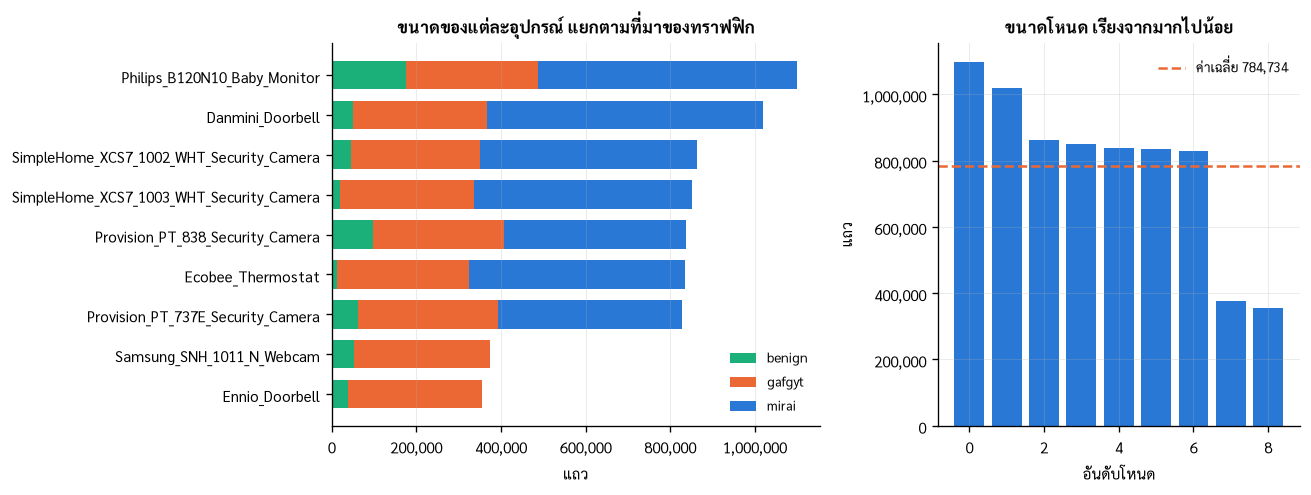

In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.2), gridspec_kw={"width_ratios": [1.35, 1]})

order = per_device.index
bottom = np.zeros(len(order))
for family, colour in [("benign", C["aqua"]), ("gafgyt", C["orange"]), ("mirai", C["blue"])]:
    if family not in per_device:
        continue
    vals = per_device.loc[order, family].to_numpy()
    ax1.barh(order, vals, left=bottom, color=colour, label=family, height=0.72)
    bottom += vals
ax1.set_title("ขนาดของแต่ละอุปกรณ์ แยกตามที่มาของทราฟฟิก")
ax1.set_xlabel("แถว")
ax1.xaxis.set_major_formatter(thousands)
ax1.invert_yaxis()
ax1.legend(frameon=False, fontsize=8, loc="lower right")
ax1.grid(axis="y", visible=False)

sorted_sizes = np.sort(device_sizes)[::-1]
ax2.bar(range(len(sorted_sizes)), sorted_sizes, color=C["blue"])
ax2.axhline(device_sizes.mean(), color=C["orange"], linewidth=1.5, linestyle="--",
            label=f"ค่าเฉลี่ย {device_sizes.mean():,.0f}")
ax2.set_title("ขนาดโหนด เรียงจากมากไปน้อย")
ax2.set_xlabel("อันดับโหนด")
ax2.set_ylabel("แถว")
ax2.yaxis.set_major_formatter(thousands)
ax2.legend(frameon=False, fontsize=8)

plt.tight_layout()
plt.show()

### อุปกรณ์ไหนเจอการโจมตีแบบไหน

ไม่ใช่แค่ปริมาณข้อมูลที่ต่างกัน แต่ **ชุดคลาสที่แต่ละโหนดเคยเห็นก็ไม่เหมือนกัน**
Ennio_Doorbell กับ Samsung webcam ไม่เคยโดน Mirai เลย โฟลเดอร์ mirai ของสองตัวนี้ไม่มีอยู่จริง
โมเดลท้องถิ่นของมันจึงไม่มีทางรู้จักการโจมตีตระกูลนั้นถ้าไม่เรียนรู้ร่วมกับโหนดอื่น

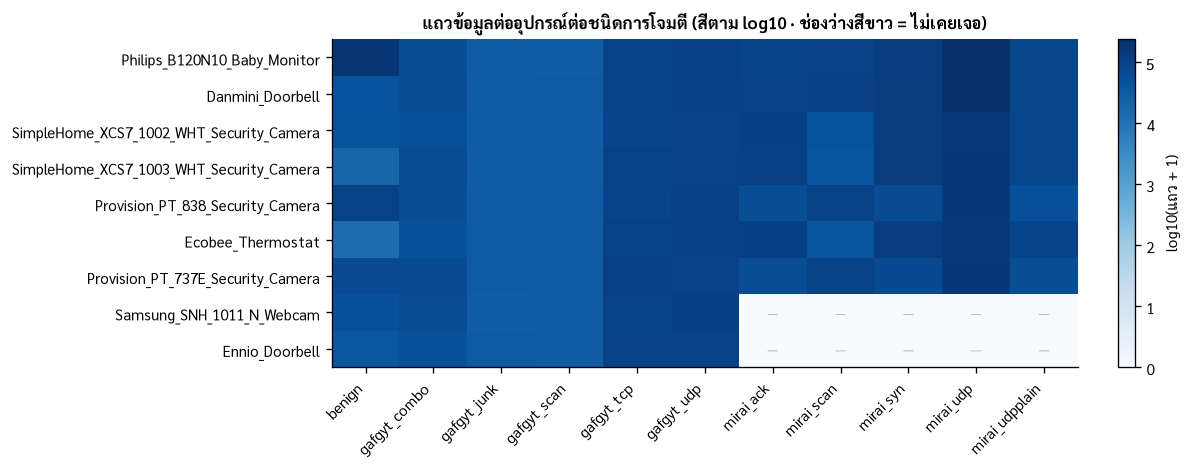

จำนวนคลาสที่แต่ละอุปกรณ์ไม่เคยเห็น (จากทั้งหมด 11 คลาส):
device
Philips_B120N10_Baby_Monitor                0
Danmini_Doorbell                            0
SimpleHome_XCS7_1002_WHT_Security_Camera    0
SimpleHome_XCS7_1003_WHT_Security_Camera    0
Provision_PT_838_Security_Camera            0
Ecobee_Thermostat                           0
Provision_PT_737E_Security_Camera           0
Samsung_SNH_1011_N_Webcam                   5
Ennio_Doorbell                              5


In [6]:
matrix = nb.pivot_table(index="device", columns="attack", values="rows",
                        aggfunc="sum", fill_value=0).loc[per_device.index]
missing = (matrix == 0).sum(axis=1)

fig, ax = plt.subplots(figsize=(10, 4))
shown = np.log10(matrix.to_numpy() + 1)
im = ax.imshow(shown, cmap="Blues", aspect="auto")
ax.set_xticks(range(matrix.shape[1]), matrix.columns, rotation=45, ha="right")
ax.set_yticks(range(matrix.shape[0]), matrix.index)
ax.set_title("แถวข้อมูลต่ออุปกรณ์ต่อชนิดการโจมตี (สีตาม log10 · ช่องว่างสีขาว = ไม่เคยเจอ)")
ax.grid(False)
for i in range(matrix.shape[0]):
    for j in range(matrix.shape[1]):
        if matrix.iat[i, j] == 0:
            ax.text(j, i, "—", ha="center", va="center", color="#b0b8b5", fontsize=8)
plt.colorbar(im, ax=ax, label="log10(แถว + 1)", fraction=0.025)
plt.tight_layout()
plt.show()

print("จำนวนคลาสที่แต่ละอุปกรณ์ไม่เคยเห็น (จากทั้งหมด %d คลาส):" % matrix.shape[1])
print(missing.to_string())

### สรุป label skew ของ partition ชุดนี้

ความเอียงมีสองชั้นที่ต้องแยกกันพูดในรายงาน ชั้นแรกคือปริมาณข้อมูลต่อโหนด
ชั้นที่สองคือชุดคลาสที่โหนดนั้นเคยเห็น ซึ่งรุนแรงกว่าและเป็นชั้นที่ทำให้ต้องเรียนรู้ร่วมกันจริง ๆ

In [7]:
missing_per_device = (matrix == 0).sum(axis=1)
present_per_class = (matrix > 0).sum(axis=0)

pd.DataFrame([{
    "โหนด": len(matrix),
    "คลาสทั้งหมด": int(matrix.shape[1]),
    "โหนดที่ขาดอย่างน้อยหนึ่งคลาส": int((missing_per_device > 0).sum()),
    "ขาดมากสุด (คลาส)": int(missing_per_device.max()),
    "คลาสที่ไม่ได้มีครบทุกโหนด": int((present_per_class < len(matrix)).sum()),
    "seed ที่ใช้แบ่ง": "ไม่มี",
}])

,โหนด,คลาสทั้งหมด,โหนดที่ขาดอย่างน้อยหนึ่งคลาส,ขาดมากสุด (คลาส),คลาสที่ไม่ได้มีครบทุกโหนด,seed ที่ใช้แบ่ง
0,9,11,2,5,5,ไม่มี


In [8]:
# คลาสไหนหายไปจากโหนดไหนบ้าง — ตารางนี้ใช้อ้างในรายงานได้ตรง ๆ
gaps = {device: sorted(matrix.columns[matrix.loc[device] == 0])
        for device in matrix.index if (matrix.loc[device] == 0).any()}
for device, classes in gaps.items():
    print(f"{device}: ขาด {len(classes)} คลาส — {', '.join(classes)}")

Samsung_SNH_1011_N_Webcam: ขาด 5 คลาส — mirai_ack, mirai_scan, mirai_syn, mirai_udp, mirai_udpplain
Ennio_Doorbell: ขาด 5 คลาส — mirai_ack, mirai_scan, mirai_syn, mirai_udp, mirai_udpplain


ความเอียงระดับนี้มาจากเหตุการณ์จริง ไม่ใช่การสุ่ม สองอุปกรณ์นั้นไม่เคยติด Mirai
ดังนั้นการแบ่งนี้**รันซ้ำกี่ครั้งก็ได้รูปเดิม** ไม่มีพารามิเตอร์ให้ปรับและไม่มี seed ให้เปลี่ยน
ซึ่งเป็นคุณสมบัติที่ทำให้ตัวเลขข้ามงานวิจัยเทียบกันได้

### 115 คอลัมน์นั้นคืออะไรบ้าง

ชื่อคอลัมน์ไม่ได้ตั้งมั่ว แต่เป็นรหัสสามส่วนประกอบกัน: **สตรีม** ที่สรุปสถิติ ·
**หน้าต่างเวลา** ที่ย้อนหลังไปแค่ไหน · **สถิติ** ที่คำนวณ
เช่น `HH_L5_variance` คือความแปรปรวนของทราฟฟิกจากต้นทางไปปลายทาง ในหน้าต่างที่สลายเร็วสุด

การรู้โครงนี้มีผลต่อการออกแบบโมเดล เพราะฟีเจอร์ในสตรีมเดียวกันต่างหน้าต่างเวลา
มักซ้ำซ้อนกันสูง เลือกมาบางส่วนก็อาจพอ

In [9]:
sample_device = per_device.index[0]
sample = pd.read_csv(NBAIOT / sample_device / "benign_traffic.csv", nrows=2000)
print(f"อุปกรณ์ตัวอย่าง: {sample_device} · {sample.shape[1]} คอลัมน์")


def parse_column(name: str) -> dict:
    """แยกชื่อคอลัมน์เป็น สตรีม / หน้าต่างเวลา / สถิติ — มีสองรูปแบบคือมี L กับไม่มี"""
    parts = name.split("_")
    window = next((p for p in parts if p.startswith("L") and p[1:].replace(".", "").isdigit()), None)
    if window:
        i = parts.index(window)
        return {"column": name, "stream": "_".join(parts[:i]), "window": window,
                "stat": "_".join(parts[i + 1:])}
    return {"column": name, "stream": "_".join(parts[:-1]), "window": "-", "stat": parts[-1]}


schema = pd.DataFrame([parse_column(c) for c in sample.columns])
schema.head(6)

อุปกรณ์ตัวอย่าง: Philips_B120N10_Baby_Monitor · 115 คอลัมน์


,column,stream,window,stat
0,MI_dir_L5_weight,MI_dir,L5,weight
1,MI_dir_L5_mean,MI_dir,L5,mean
2,MI_dir_L5_variance,MI_dir,L5,variance
3,MI_dir_L3_weight,MI_dir,L3,weight
4,MI_dir_L3_mean,MI_dir,L3,mean
5,MI_dir_L3_variance,MI_dir,L3,variance


In [10]:
# สตรีมไหนมีกี่คอลัมน์ และให้สถิติอะไรบ้าง
stream_summary = (schema.groupby("stream")
                  .agg(คอลัมน์=("column", "size"),
                       หน้าต่างเวลา=("window", lambda v: len(set(v) - {"-"})),
                       สถิติ=("stat", lambda v: ", ".join(sorted(set(v)))))
                  .sort_values("คอลัมน์", ascending=False))
stream_summary

,คอลัมน์,หน้าต่างเวลา,สถิติ
stream,,,
HH,35,5,"covariance, magnitude, mean, pcc, radius, std,..."
HpHp,35,5,"covariance, magnitude, mean, pcc, radius, std,..."
H,15,5,"mean, variance, weight"
HH_jit,15,5,"mean, variance, weight"
MI_dir,15,5,"mean, variance, weight"


สตรีมทั้งห้าคือมุมมองที่ต่างกันของแพ็กเก็ตเดียวกัน ตามที่เอกสารของชุดข้อมูลอธิบายไว้:
`MI` คือทราฟฟิกจากต้นทางระดับ MAC+IP · `H` ระดับ IP · `HH` คู่ต้นทาง-ปลายทาง ·
`HH_jit` คือ jitter ของคู่นั้น · `HpHp` คู่ต้นทาง-ปลายทางระดับพอร์ต

หน้าต่างเวลาห้าค่า (`L5` ถึง `L0.01`) คือค่าคงที่การสลายของหน้าต่างถ่วงน้ำหนัก
ค่ามากคือมองย้อนหลังสั้น ค่าน้อยคือจำได้ยาว

In [11]:
# คุณภาพข้อมูลระดับคอลัมน์ วัดจากตัวอย่างที่คละทุกคลาสของอุปกรณ์เดียวกัน
files = [(NBAIOT / sample_device / "benign_traffic.csv", "benign")]
for fam in ("gafgyt", "mirai"):
    d = NBAIOT / sample_device / f"{fam}_attacks"
    files += [(f, f"{fam}_{f.stem}") for f in sorted(d.glob("*.csv"))] if d.is_dir() else []

frames, labels = [], []
for path, label in files:
    part = pd.read_csv(path, nrows=3000)
    frames.append(part)
    labels.extend([label] * len(part))       # ใส่ป้ายทีเดียวหลัง concat จะได้ไม่แตกส่วน
X = pd.concat(frames, ignore_index=True)
labels = pd.Series(labels, name="label")   # เก็บป้ายแยก ไม่ยัดกลับเข้า frame ที่มี 115 คอลัมน์

quality = pd.DataFrame([{
    "แถวที่สุ่มมา": len(X),
    "คอลัมน์ตัวเลข": int(X.select_dtypes("number").shape[1]),
    "ค่าว่าง": int(X.isna().sum().sum()),
    "คอลัมน์ค่าคงที่": int((X.nunique() <= 1).sum()),
    "ค่าติดลบ": int((X < 0).any().sum()),
    "ค่าสูงสุดที่เจอ": f"{X.to_numpy().max():,.0f}",
}])
quality

,แถวที่สุ่มมา,คอลัมน์ตัวเลข,ค่าว่าง,คอลัมน์ค่าคงที่,ค่าติดลบ,ค่าสูงสุดที่เจอ
0,33000,115,0,0,20,"568,259,146,834,389,824"


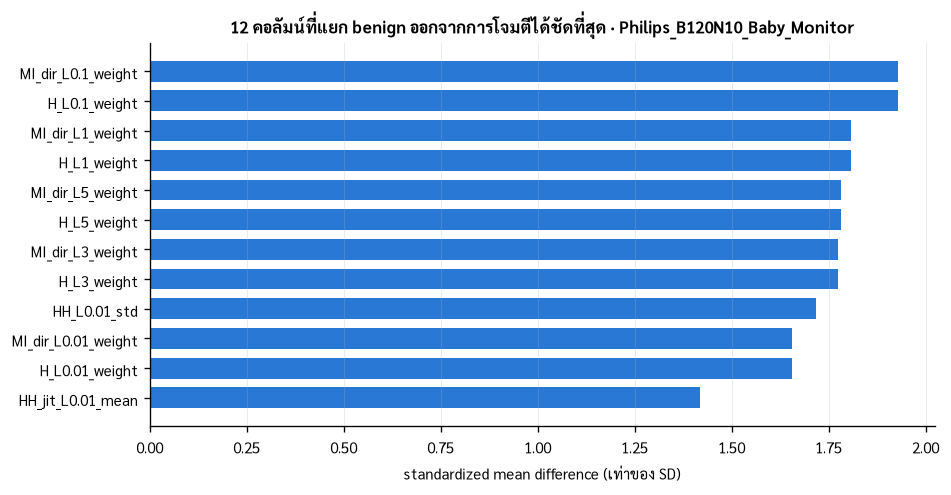

สตรีมของ 20 คอลัมน์แรกที่แยกได้ดีที่สุด:
stream
MI_dir    6
H         6
HH_jit    5
HH        3


In [12]:
# ฟีเจอร์ไหนแยก benign ออกจากการโจมตีได้ชัดที่สุด
# ใช้ standardized mean difference: ต่างกันกี่เท่าของส่วนเบี่ยงเบนมาตรฐานรวม
benign_rows = (labels == "benign").to_numpy()
mu_b, mu_a = X[benign_rows].mean(), X[~benign_rows].mean()
sd = np.sqrt((X[benign_rows].var() + X[~benign_rows].var()) / 2).replace(0, np.nan)
separation = ((mu_a - mu_b) / sd).abs().sort_values(ascending=False)

top = separation.head(12)[::-1]
fig, ax = plt.subplots(figsize=(8, 4.2))
ax.barh(top.index, top.to_numpy(), color=C["blue"], height=0.7)
ax.set_xlabel("standardized mean difference (เท่าของ SD)")
ax.set_title(f"12 คอลัมน์ที่แยก benign ออกจากการโจมตีได้ชัดที่สุด · {sample_device}")
ax.grid(axis="y", visible=False)
plt.tight_layout()
plt.show()

print("สตรีมของ 20 คอลัมน์แรกที่แยกได้ดีที่สุด:")
print(schema.set_index("column").loc[separation.head(20).index, "stream"].value_counts().to_string())

In [13]:
# ความซ้ำซ้อน: คู่คอลัมน์ที่สหสัมพันธ์เกิน 0.95 แปลว่าข้อมูลจริงมีมิติน้อยกว่า 115
corr = X.corr(numeric_only=True).abs()
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
pairs = upper.stack()
redundant = pairs[pairs > 0.95]

print(f"คู่คอลัมน์ทั้งหมด {len(pairs):,} คู่")
print(f"สหสัมพันธ์เกิน 0.95: {len(redundant):,} คู่")
print(f"คอลัมน์ที่ไปซ้ำกับคอลัมน์อื่นอย่างน้อยหนึ่งตัว: "
      f"{len(set(redundant.index.get_level_values(0)) | set(redundant.index.get_level_values(1)))} จาก {X.shape[1]}")
print()
print("ห้าคู่ที่ซ้ำกันที่สุด:")
print(redundant.sort_values(ascending=False).head(5).to_string())

คู่คอลัมน์ทั้งหมด 13,225 คู่
สหสัมพันธ์เกิน 0.95: 234 คู่
คอลัมน์ที่ไปซ้ำกับคอลัมน์อื่นอย่างน้อยหนึ่งตัว: 96 จาก 115

ห้าคู่ที่ซ้ำกันที่สุด:
HH_L1_weight     HH_jit_L1_weight       1.0
HH_L0.1_weight   HH_jit_L0.1_weight     1.0
HH_L0.01_weight  HH_jit_L0.01_weight    1.0
HH_L3_weight     HH_jit_L3_weight       1.0
HH_L5_weight     HH_jit_L5_weight       1.0


---

# 2 · Elliptic

ธุรกรรมบิตคอยน์จริง 203,769 โหนด เชื่อมกันเป็นกราฟ 234,355 เส้น
มี 166 ฟีเจอร์ต่อธุรกรรมตามเปเปอร์ (ในไฟล์คือ time step หนึ่งคอลัมน์ บวกฟีเจอร์ตัวเลข 165 คอลัมน์)
และทุกธุรกรรมถูกตีตราเวลาไว้เป็น 49 time step
ป้ายกำกับมีสามค่า คือ licit, illicit และ unknown ซึ่งเป็นส่วนใหญ่ของข้อมูล

ธีมของชุดนี้เข้ากับโปรเจกต์สองชั้น: ข้อมูลเองก็มาจากบล็อกเชน
และเหตุผลที่ต้องมี ledger ตรวจสอบได้ก็คือผู้กำกับดูแลทางการเงิน ซึ่งเป็นเรื่องเล่าที่แข็งกว่าสายการแพทย์

In [14]:
require(ELLIPTIC / "elliptic_txs_features.csv", "ไฟล์ Elliptic")

classes = pd.read_csv(ELLIPTIC / "elliptic_txs_classes.csv")
edges = pd.read_csv(ELLIPTIC / "elliptic_txs_edgelist.csv")
features = pd.read_csv(ELLIPTIC / "elliptic_txs_features.csv", header=None)
features.columns = ["txId", "time_step"] + [f"f{i}" for i in range(1, features.shape[1] - 1)]

label_name = {"1": "illicit", "2": "licit", "unknown": "unknown"}
classes["label"] = classes["class"].astype(str).map(label_name)

print(f"โหนด {len(features):,} · เส้นเชื่อม {len(edges):,} · ฟีเจอร์ {features.shape[1] - 2} · time step {features['time_step'].nunique()}")
classes["label"].value_counts().rename("ธุรกรรม").to_frame().assign(
    สัดส่วน=lambda d: (d["ธุรกรรม"] / d["ธุรกรรม"].sum()).round(4))

โหนด 203,769 · เส้นเชื่อม 234,355 · ฟีเจอร์ 165 · time step 49


,ธุรกรรม,สัดส่วน
label,,
unknown,157205,0.7715
licit,42019,0.2062
illicit,4545,0.0223


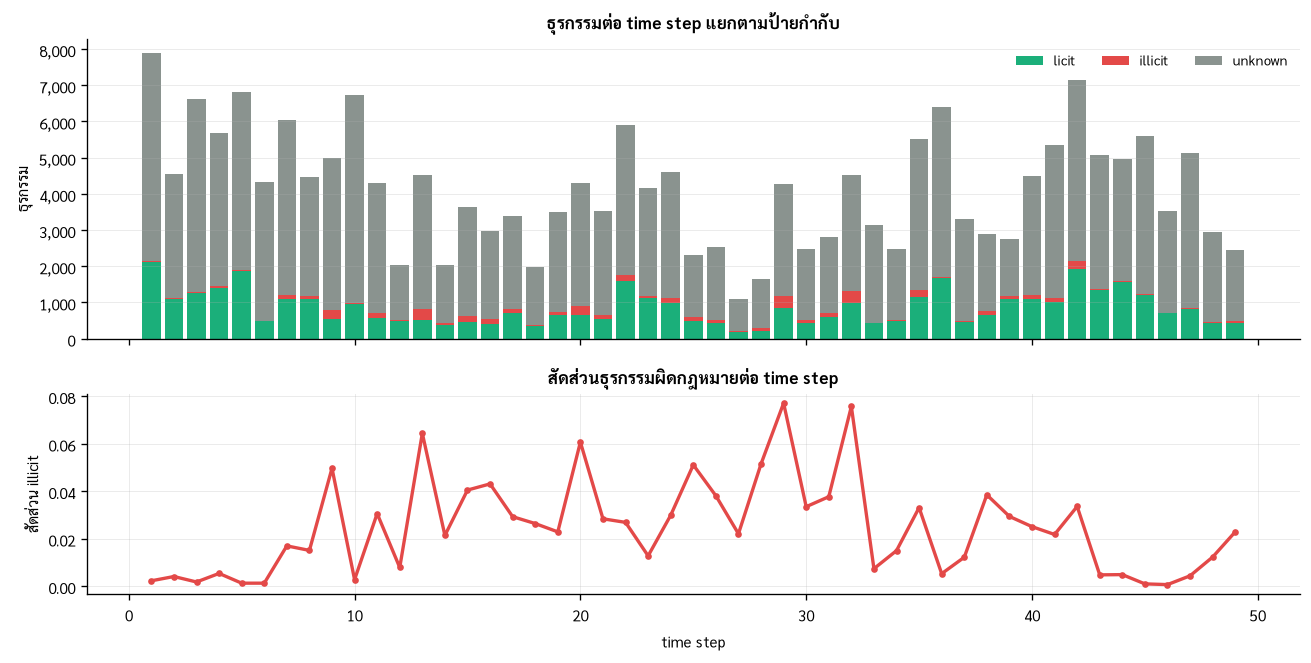

time step ที่สัดส่วน illicit สูงสุดห้าอันดับ:
time_step
29    0.0770
32    0.0756
13    0.0643
20    0.0606
28    0.0514


In [15]:
df = features[["txId", "time_step"]].merge(classes[["txId", "label"]], on="txId", how="left")
by_step = df.pivot_table(index="time_step", columns="label", values="txId", aggfunc="count", fill_value=0)
by_step["illicit_rate"] = (by_step.get("illicit", 0) / by_step.sum(axis=1)).round(4)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 5.6), sharex=True,
                               gridspec_kw={"height_ratios": [1.5, 1]})

bottom = np.zeros(len(by_step))
for label, colour in [("licit", C["aqua"]), ("illicit", C["red"]), ("unknown", C["grey"])]:
    if label not in by_step:
        continue
    ax1.bar(by_step.index, by_step[label], bottom=bottom, color=colour, label=label, width=0.82)
    bottom += by_step[label].to_numpy()
ax1.set_ylabel("ธุรกรรม")
ax1.set_title("ธุรกรรมต่อ time step แยกตามป้ายกำกับ")
ax1.yaxis.set_major_formatter(thousands)
ax1.legend(frameon=False, fontsize=8, ncol=3)
ax1.grid(axis="x", visible=False)

ax2.plot(by_step.index, by_step["illicit_rate"], color=C["red"], linewidth=2, marker="o", markersize=3)
ax2.set_xlabel("time step")
ax2.set_ylabel("สัดส่วน illicit")
ax2.set_title("สัดส่วนธุรกรรมผิดกฎหมายต่อ time step")

plt.tight_layout()
plt.show()

print("time step ที่สัดส่วน illicit สูงสุดห้าอันดับ:")
print(by_step["illicit_rate"].nlargest(5).to_string())

ช่วงที่สัดส่วน illicit ตกฮวบหลัง time step 43 คือจุดที่ตลาดมืดแห่งหนึ่งถูกปิด
ซึ่งเป็นเหตุการณ์จริงที่ Weber et al. (2019) ใช้เป็นตัวอย่างว่าโมเดลที่เทรนกับอดีต
ทำงานแย่ลงทันทีเมื่อโลกเปลี่ยน — ประเด็นนี้ใช้กับ swarm learning ได้ตรง ๆ
เพราะมันคือเหตุผลว่าทำไมต้องเทรนต่อเนื่องเป็นรอบ ๆ แทนที่จะเทรนครั้งเดียวจบ

### 165 คอลัมน์ของ Elliptic เป็นอะไรบ้าง

ต่างจาก N-BaIoT ตรงที่ชื่อคอลัมน์ถูกลบทิ้ง เหลือแค่ลำดับ เพราะผู้เผยแพร่ไม่เปิดเผยสูตรฟีเจอร์
สิ่งที่รู้จากเปเปอร์คือ **94 คอลัมน์แรกเป็นฟีเจอร์เฉพาะตัวธุรกรรม** (นับ time step ด้วย)
เช่น ค่าธรรมเนียม จำนวน input/output ส่วน **72 คอลัมน์ที่เหลือเป็นค่าที่รวมมาจากเพื่อนบ้านในกราฟ**
คือค่าสูงสุด ต่ำสุด และค่าเฉลี่ยของฟีเจอร์เดียวกันในธุรกรรมที่เชื่อมถึงกัน

การแยกสองกลุ่มนี้สำคัญกับงาน federated เพราะกลุ่มหลังต้องใช้ข้อมูลเพื่อนบ้าน
ถ้าแบ่งกราฟให้คนละองค์กรถือคนละส่วน ฟีเจอร์กลุ่มนี้จะคำนวณไม่ได้ครบเหมือนตอนรวมศูนย์

In [16]:
feature_cols = [c for c in features.columns if c.startswith("f")]
local_cols = feature_cols[:93]        # 93 + time_step = 94 ตามเปเปอร์
agg_cols = feature_cols[93:]          # 72 คอลัมน์ที่รวมจากเพื่อนบ้าน

pd.DataFrame([
    {"กลุ่ม": "local (เฉพาะธุรกรรมนั้น)", "คอลัมน์": len(local_cols),
     "ตัวอย่างชื่อ": f"{local_cols[0]} … {local_cols[-1]}"},
    {"กลุ่ม": "aggregated (จากเพื่อนบ้าน)", "คอลัมน์": len(agg_cols),
     "ตัวอย่างชื่อ": f"{agg_cols[0]} … {agg_cols[-1]}"},
    {"กลุ่ม": "time_step", "คอลัมน์": 1, "ตัวอย่างชื่อ": "time_step"},
    {"กลุ่ม": "txId (ไม่ใช่ฟีเจอร์)", "คอลัมน์": 1, "ตัวอย่างชื่อ": "txId"},
])

,กลุ่ม,คอลัมน์,ตัวอย่างชื่อ
0,local (เฉพาะธุรกรรมนั้น),93,f1 … f93
1,aggregated (จากเพื่อนบ้าน),72,f94 … f165
2,time_step,1,time_step
3,txId (ไม่ใช่ฟีเจอร์),1,txId


In [17]:
# คุณภาพข้อมูลระดับคอลัมน์ และเช็กว่าถูก standardize มาแล้วหรือยัง
F = features[feature_cols]
col_mean, col_std = F.mean(), F.std()

quality_ell = pd.DataFrame([{
    "แถว": len(F),
    "คอลัมน์ฟีเจอร์": F.shape[1],
    "ค่าว่าง": int(F.isna().sum().sum()),
    "คอลัมน์ค่าคงที่": int((F.nunique() <= 1).sum()),
    "ค่าเฉลี่ยของ mean รายคอลัมน์": round(col_mean.mean(), 4),
    "ค่าเฉลี่ยของ sd รายคอลัมน์": round(col_std.mean(), 4),
    "คอลัมน์ที่ |mean| > 0.1": int((col_mean.abs() > 0.1).sum()),
}])
quality_ell

,แถว,คอลัมน์ฟีเจอร์,ค่าว่าง,คอลัมน์ค่าคงที่,ค่าเฉลี่ยของ mean รายคอลัมน์,ค่าเฉลี่ยของ sd รายคอลัมน์,คอลัมน์ที่ |mean| > 0.1
0,203769,165,0,0,0.0,1.0,0


ค่าเฉลี่ยใกล้ศูนย์และส่วนเบี่ยงเบนมาตรฐานใกล้หนึ่งทุกคอลัมน์ แปลว่า
**ข้อมูลถูก standardize มาให้แล้ว** ไม่ต้องทำซ้ำในขั้นเตรียมข้อมูล
ซึ่งต่างจาก N-BaIoT ที่ค่าดิบยังอยู่ในหน่วยจริงและกระจายกว้างมาก จำเป็นต้องสเกลก่อนเทรน

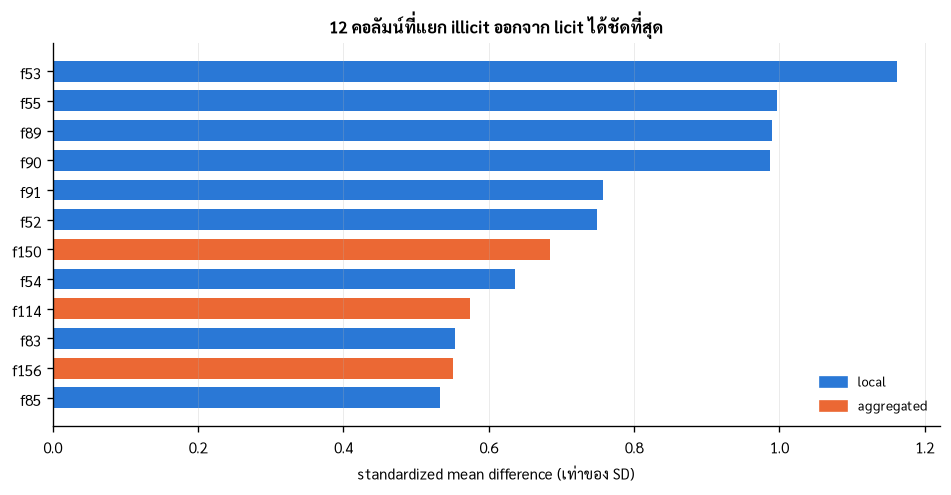

สัดส่วนกลุ่มใน 30 คอลัมน์ที่แยกได้ดีที่สุด:
local         23
aggregated     7


In [18]:
# คอลัมน์ไหนแยก licit ออกจาก illicit ได้ชัดที่สุด และอยู่กลุ่มไหน
lab = features[["txId"]].merge(classes[["txId", "label"]], on="txId", how="left")["label"]
is_illicit, is_licit = (lab == "illicit").to_numpy(), (lab == "licit").to_numpy()

mu_i, mu_l = F[is_illicit].mean(), F[is_licit].mean()
sd_pooled = np.sqrt((F[is_illicit].var() + F[is_licit].var()) / 2).replace(0, np.nan)
sep_ell = ((mu_i - mu_l) / sd_pooled).abs().sort_values(ascending=False)

group_of = {c: ("local" if c in set(local_cols) else "aggregated") for c in feature_cols}
top_ell = sep_ell.head(12)[::-1]

fig, ax = plt.subplots(figsize=(8, 4.2))
ax.barh(top_ell.index, top_ell.to_numpy(),
        color=[C["blue"] if group_of[c] == "local" else C["orange"] for c in top_ell.index], height=0.7)
ax.set_xlabel("standardized mean difference (เท่าของ SD)")
ax.set_title("12 คอลัมน์ที่แยก illicit ออกจาก licit ได้ชัดที่สุด")
ax.grid(axis="y", visible=False)
handles = [plt.Rectangle((0, 0), 1, 1, color=C["blue"]), plt.Rectangle((0, 0), 1, 1, color=C["orange"])]
ax.legend(handles, ["local", "aggregated"], frameon=False, fontsize=8, loc="lower right")
plt.tight_layout()
plt.show()

print("สัดส่วนกลุ่มใน 30 คอลัมน์ที่แยกได้ดีที่สุด:")
print(pd.Series([group_of[c] for c in sep_ell.head(30).index]).value_counts().to_string())

In [19]:
# ความซ้ำซ้อนของฟีเจอร์ วัดแบบเดียวกับ N-BaIoT เพื่อให้เทียบกันได้
corr_ell = F.corr().abs()
upper_ell = corr_ell.where(np.triu(np.ones(corr_ell.shape), k=1).astype(bool))
pairs_ell = upper_ell.stack()
redundant_ell = pairs_ell[pairs_ell > 0.95]

print(f"คู่คอลัมน์ทั้งหมด {len(pairs_ell):,} คู่")
print(f"สหสัมพันธ์เกิน 0.95: {len(redundant_ell):,} คู่")
print(f"คอลัมน์ที่ไปซ้ำกับคอลัมน์อื่น: "
      f"{len(set(redundant_ell.index.get_level_values(0)) | set(redundant_ell.index.get_level_values(1)))} "
      f"จาก {F.shape[1]}")

คู่คอลัมน์ทั้งหมด 27,225 คู่
สหสัมพันธ์เกิน 0.95: 96 คู่
คอลัมน์ที่ไปซ้ำกับคอลัมน์อื่น: 110 จาก 165


### จุดอ่อนของ Elliptic สำหรับงาน federated

ชุดนี้ไม่มีเจ้าของข้อมูลติดมาด้วย มีแค่กราฟเดียวก้อนเดียว
ถ้าจะทำเป็น 5 องค์กรต้องสังเคราะห์ partition เอง ซึ่งเป็นปัญหาเดียวกับที่คุณบอกว่า
CIC-IDS2017 ทำให้เทียบข้าม paper ไม่ได้

เซลล์ข้างล่างลองสองวิธีแบ่งที่พอจะอ้างเหตุผลได้ แล้ววัดว่าแต่ละวิธีเอียงแค่ไหน
เทียบกับ N-BaIoT ที่ไม่ต้องแบ่งเอง

In [20]:
rng = np.random.default_rng(42)
labelled = df[df["label"] != "unknown"].copy()

# วิธี ก: แบ่งตามช่วงเวลา — ธนาคารที่เข้าร่วมคนละช่วง
# แบ่ง time step ต่อเนื่องออกเป็นห้าช่วง (qcut ใช้ไม่ได้เพราะขอบซ้ำกันเมื่อมีแค่ 49 ค่า)
step_groups = {step: f"silo{i+1}"
               for i, chunk in enumerate(np.array_split(np.sort(labelled["time_step"].unique()), 5))
               for step in chunk}
time_bins = labelled["time_step"].map(step_groups)
# วิธี ข: สุ่มแบ่งเท่า ๆ กัน — ไม่มีเหตุผลรองรับ แต่เป็นสิ่งที่งานส่วนใหญ่ทำ
random_bins = pd.Series(rng.integers(0, 5, len(labelled)), index=labelled.index).map(lambda i: f"silo{i+1}")

rows = []
for name, assignment in [("แบ่งตามช่วงเวลา", time_bins), ("สุ่มแบ่ง", random_bins)]:
    sizes = labelled.groupby(assignment, observed=True).size()
    illicit_rate = labelled.assign(g=assignment).groupby("g", observed=True)["label"].apply(
        lambda s: (s == "illicit").mean())
    rows.append({"วิธีแบ่ง": name, "เล็กสุด": int(sizes.min()), "ใหญ่สุด": int(sizes.max()),
                 "ใหญ่/เล็ก": round(sizes.max() / sizes.min(), 2), "gini": round(gini(sizes.to_numpy()), 3),
                 "illicit ต่ำสุด": round(illicit_rate.min(), 3), "illicit สูงสุด": round(illicit_rate.max(), 3)})

rows.append({"วิธีแบ่ง": "N-BaIoT ตามอุปกรณ์ (ไม่ต้องแบ่ง)", "เล็กสุด": int(device_sizes.min()),
             "ใหญ่สุด": int(device_sizes.max()), "ใหญ่/เล็ก": round(device_sizes.max() / device_sizes.min(), 2),
             "gini": round(gini(device_sizes), 3), "illicit ต่ำสุด": None, "illicit สูงสุด": None})
pd.DataFrame(rows)

,วิธีแบ่ง,เล็กสุด,ใหญ่สุด,ใหญ่/เล็ก,gini,illicit ต่ำสุด,illicit สูงสุด
0,แบ่งตามช่วงเวลา,6421,12468,1.94,0.121,0.042,0.194
1,สุ่มแบ่ง,9243,9447,1.02,0.004,0.095,0.101
2,N-BaIoT ตามอุปกรณ์ (ไม่ต้องแบ่ง),355500,1098677,3.09,0.157,NaN,NaN


---

# 3 · Camelyon17-WILDS

**หมายเหตุเรื่องชื่อก่อน** เพราะสับสนกันง่าย: FLamby มีชุดชื่อ **Fed-Camelyon16** ซึ่งมาจาก
CAMELYON16 และมี **2 ศูนย์** ไม่ใช่ 5 ส่วนชุดที่มี **5 ศูนย์** คือ CAMELYON17 ซึ่งเป็นการแข่งขันคนละปี
ไม่ได้อยู่ใน FLamby

CAMELYON17 ตัวเต็มเป็นภาพสไลด์ทั้งใบ 1,000 ใบ รวมกับ CAMELYON16 แล้วเป็น 2.95 TB
โหลดมาทั้งก้อนไม่ไหวบนเครื่องนี้ แต่มีเวอร์ชันที่ตัดเป็นแพตช์ไว้แล้วชื่อ **Camelyon17-WILDS**
จากทีม WILDS ของ Stanford: แพตช์ 96×96 จำนวน 455,954 ใบ จากโรงพยาบาลเดียวกันทั้ง 5 แห่ง
ขนาดโหลดราว 10 GB ซึ่งรันบนเครื่องนี้ได้ และเป็นเวอร์ชันที่งานวิจัยสาย domain shift ใช้อ้างกัน

```bash
cd "poc/Finding Dataset/data"
mkdir -p camelyon17 && cd camelyon17
curl -L -o camelyon17_v1.0.tar.gz \
  "https://worksheets.codalab.org/rest/bundles/0xe45e15f39fb54e9d9e919556af67aabe/contents/blob/"

# หยุดโหลดกลางทางได้ เพราะ metadata.csv อยู่ต้นไฟล์ tar
# แตกไฟล์ที่โหลดมาแล้วได้เลย tar จะบ่นตอนจบแล้วหยุด ซึ่งไม่เป็นไร
mkdir -p camelyon17_v1.0 && tar -xzf camelyon17_v1.0.tar.gz -C camelyon17_v1.0 2>/dev/null
```

**โน้ตบุ๊กนี้ใช้ไฟล์ที่โหลดมาบางส่วน** คือ `metadata.csv` เต็ม (ครบทั้ง 455,954 แพตช์ 5 ศูนย์)
บวกไฟล์ภาพเท่าที่โหลดทัน สถิติระดับ partition จึงเป็นของจริงทั้งชุด
ส่วนการวัดสีต้องเปิดไฟล์ภาพ จึงทำได้เฉพาะศูนย์ที่มีไฟล์อยู่ ซึ่งเซลล์นั้นรายงานไว้ว่าครอบคลุมศูนย์ไหนบ้าง

In [21]:
CAMELYON = DATA / "camelyon17"
cam_root = next((d for d in (CAMELYON / "camelyon17_v1.0", CAMELYON) if (d / "metadata.csv").exists()), None)
require(cam_root / "metadata.csv" if cam_root else CAMELYON / "metadata.csv", "metadata ของ Camelyon17-WILDS")

cam = pd.read_csv(cam_root / "metadata.csv", index_col=0)
print(f"แพตช์ {len(cam):,} ใบ · คอลัมน์: {list(cam.columns)}")
cam.head(4)

แพตช์ 455,954 ใบ · คอลัมน์: ['patient', 'node', 'x_coord', 'y_coord', 'tumor', 'slide', 'center', 'split']


,patient,node,x_coord,y_coord,tumor,slide,center,split
0,4,4,3328,21792,1,0,0,0
1,4,4,3200,22272,1,0,0,0
2,4,4,3168,22272,1,0,0,0
3,4,4,3328,21760,1,0,0,0


### partition ตามโรงพยาบาล

`center` คือหมายเลขโรงพยาบาล 0–4 ซึ่งเป็น partition ที่มากับข้อมูลเอง เหมือน N-BaIoT
ไม่ต้องสังเคราะห์ ส่วน `slide` กับ `patient` คือระดับที่ละเอียดลงไปอีก
ถ้าจะทำ swarm 5 โหนด การจับหนึ่งศูนย์เป็นหนึ่งองค์กรคือการแบ่งที่ตรงกับความเป็นจริงที่สุด

In [22]:
by_center = (cam.groupby("center")
             .agg(แพตช์=("tumor", "size"),
                  ผู้ป่วย=("patient", "nunique"),
                  สไลด์=("slide", "nunique"),
                  tumor=("tumor", "sum"))
             .assign(สัดส่วน_tumor=lambda d: (d["tumor"] / d["แพตช์"]).round(4),
                     ส่วนแบ่ง=lambda d: (d["แพตช์"] / d["แพตช์"].sum()).round(4)))
by_center

,แพตช์,ผู้ป่วย,สไลด์,tumor,สัดส่วน_tumor,ส่วนแบ่ง
center,,,,,,
0,59436,7,10,29718,0.5,0.1304
1,34904,8,10,17452,0.5,0.0766
2,85054,9,10,42527,0.5,0.1865
3,129838,10,10,64919,0.5,0.2848
4,146722,9,10,73361,0.5,0.3218


In [23]:
cam_sizes = by_center["แพตช์"].to_numpy()

pd.DataFrame([{
    "partition": "Camelyon17-WILDS · ตามโรงพยาบาล",
    "โหนด": len(cam_sizes),
    "เล็กสุด": int(cam_sizes.min()),
    "ใหญ่สุด": int(cam_sizes.max()),
    "ใหญ่/เล็ก": round(cam_sizes.max() / cam_sizes.min(), 2),
    "gini": round(gini(cam_sizes), 3),
    "tumor ต่ำสุด": by_center["สัดส่วน_tumor"].min(),
    "tumor สูงสุด": by_center["สัดส่วน_tumor"].max(),
}])

,partition,โหนด,เล็กสุด,ใหญ่สุด,ใหญ่/เล็ก,gini,tumor ต่ำสุด,tumor สูงสุด
0,Camelyon17-WILDS · ตามโรงพยาบาล,5,34904,146722,4.2,0.258,0.5,0.5


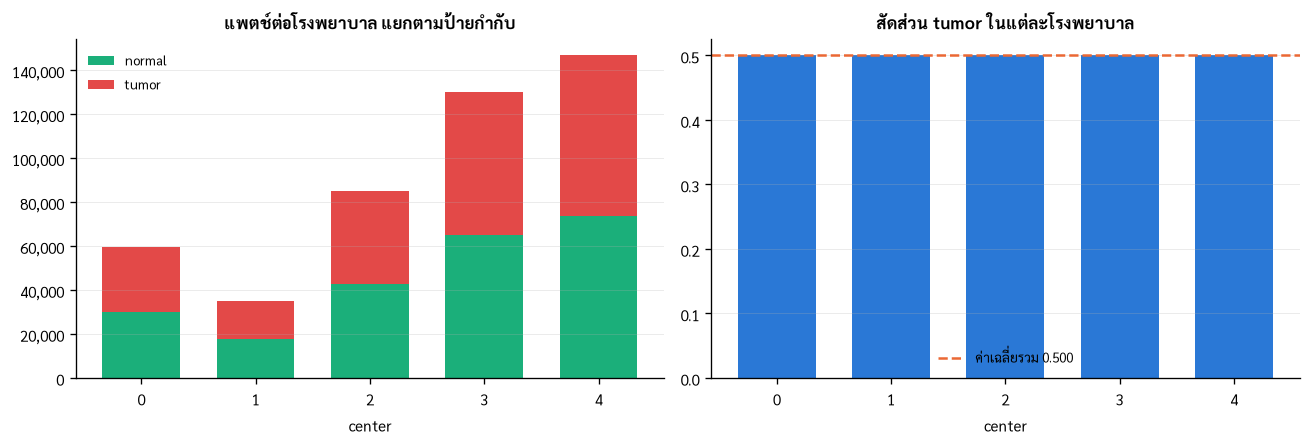

In [24]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3.8))

centers = by_center.index.astype(str)
ax1.bar(centers, by_center["แพตช์"] - by_center["tumor"], color=C["aqua"], label="normal", width=0.68)
ax1.bar(centers, by_center["tumor"], bottom=by_center["แพตช์"] - by_center["tumor"],
        color=C["red"], label="tumor", width=0.68)
ax1.set_title("แพตช์ต่อโรงพยาบาล แยกตามป้ายกำกับ")
ax1.set_xlabel("center")
ax1.yaxis.set_major_formatter(thousands)
ax1.legend(frameon=False, fontsize=8)
ax1.grid(axis="x", visible=False)

ax2.bar(centers, by_center["สัดส่วน_tumor"], color=C["blue"], width=0.68)
ax2.axhline(cam["tumor"].mean(), color=C["orange"], linestyle="--", linewidth=1.5,
            label=f"ค่าเฉลี่ยรวม {cam['tumor'].mean():.3f}")
ax2.set_title("สัดส่วน tumor ในแต่ละโรงพยาบาล")
ax2.set_xlabel("center")
ax2.legend(frameon=False, fontsize=8)
ax2.grid(axis="x", visible=False)

plt.tight_layout()
plt.show()

ตัวเลขในตารางบอกอะไรที่ต้องอ่านให้ดี: **สัดส่วน tumor เท่ากับ 0.5 พอดีทุกศูนย์**
และทุกศูนย์มี 10 สไลด์เท่ากัน นั่นไม่ใช่เรื่องบังเอิญ แต่เป็นเพราะทีม WILDS
จงใจสุ่มแพตช์ให้สมดุลตอนสร้างชุดข้อมูล

ผลคือชุดนี้ **ไม่มี label skew เลย** ต่างจากอีกสองชุดโดยสิ้นเชิง
ความเอียงที่เหลืออยู่มีสองอย่างคือปริมาณแพตช์ต่อศูนย์ (ใหญ่/เล็ก 4.2 เท่า · gini 0.258)
กับความต่างของภาพเอง ซึ่งเป็นสิ่งที่เซลล์ถัดไปวัด

### สีของสไลด์ต่างกันจริงไหม

เหตุผลที่ชุดนี้ถูกใช้ในงาน domain shift คือแต่ละโรงพยาบาลใช้เครื่องย้อมและสแกนคนละรุ่น
ภาพจึงมีโทนสีต่างกันแม้เป็นเนื้อเยื่อแบบเดียวกัน เซลล์ข้างล่างสุ่มแพตช์มาศูนย์ละไม่เกิน 300 ใบ **จากไฟล์ที่โหลดมาจริงเท่านั้น**
แล้ววัดค่าเฉลี่ยของแต่ละแชนแนลสี เพื่อดูว่าความต่างนั้นวัดออกมาเป็นตัวเลขได้จริงหรือไม่

นี่คือ non-IID อีกชนิดที่ต่างจากทั้ง N-BaIoT และ Elliptic: ไม่ใช่ปริมาณต่างหรือคลาสหาย
แต่เป็น **การกระจายของฟีเจอร์เองที่เลื่อนไปทั้งแผง**

In [25]:
from PIL import Image

# ดูก่อนว่ามีภาพของผู้ป่วยคนไหนอยู่บนดิสก์บ้าง แล้วค่อยสุ่มจากในนั้น
available = {d.name for d in (cam_root / "patches").iterdir() if d.is_dir()}
on_disk = cam[cam.apply(
    lambda r: f"patient_{int(r['patient']):03d}_node_{int(r['node'])}" in available, axis=1)]
covered = sorted(int(c) for c in on_disk["center"].unique())
print(f"ไฟล์ภาพบนดิสก์ {len(on_disk):,} แพตช์ จาก {len(cam):,} · ครอบคลุมศูนย์ {covered}")
if len(covered) < cam["center"].nunique():
    missing = sorted(int(c) for c in set(cam["center"].unique()) - set(covered))
    print(f"ยังไม่มีภาพของศูนย์ {missing} — ส่วนที่วัดสีจึงเทียบได้เฉพาะศูนย์ที่มีไฟล์")

rows = []
for center, group in on_disk.groupby("center"):
    picks = group.sample(n=min(300, len(group)), random_state=42)
    for _, r in picks.iterrows():
        path = (cam_root / "patches" /
                f"patient_{int(r['patient']):03d}_node_{int(r['node'])}" /
                f"patch_patient_{int(r['patient']):03d}_node_{int(r['node'])}"
                f"_x_{int(r['x_coord'])}_y_{int(r['y_coord'])}.png")
        if not path.exists():
            continue
        arr = np.asarray(Image.open(path).convert("RGB"), dtype=np.float32)
        rows.append({"center": center, "tumor": r["tumor"],
                     "R": arr[..., 0].mean(), "G": arr[..., 1].mean(), "B": arr[..., 2].mean(),
                     "sd": arr.std()})

colour = pd.DataFrame(rows)
colour_by_center = colour.groupby("center")[["R", "G", "B", "sd"]].mean().round(1)
colour_by_center["ตัวอย่างที่อ่านได้"] = colour.groupby("center").size()
colour_by_center

ไฟล์ภาพบนดิสก์ 84,898 แพตช์ จาก 455,954 · ครอบคลุมศูนย์ [0, 1, 2, 4]
ยังไม่มีภาพของศูนย์ [3] — ส่วนที่วัดสีจึงเทียบได้เฉพาะศูนย์ที่มีไฟล์


,R,G,B,sd,ตัวอย่างที่อ่านได้
center,,,,,
0,163.899994,116.000000,147.500000,44.599998,300
1,144.199997,107.900002,144.500000,44.299999,298
2,175.000000,130.300003,191.100006,45.000000,300
4,211.500000,185.800003,216.300003,29.500000,300


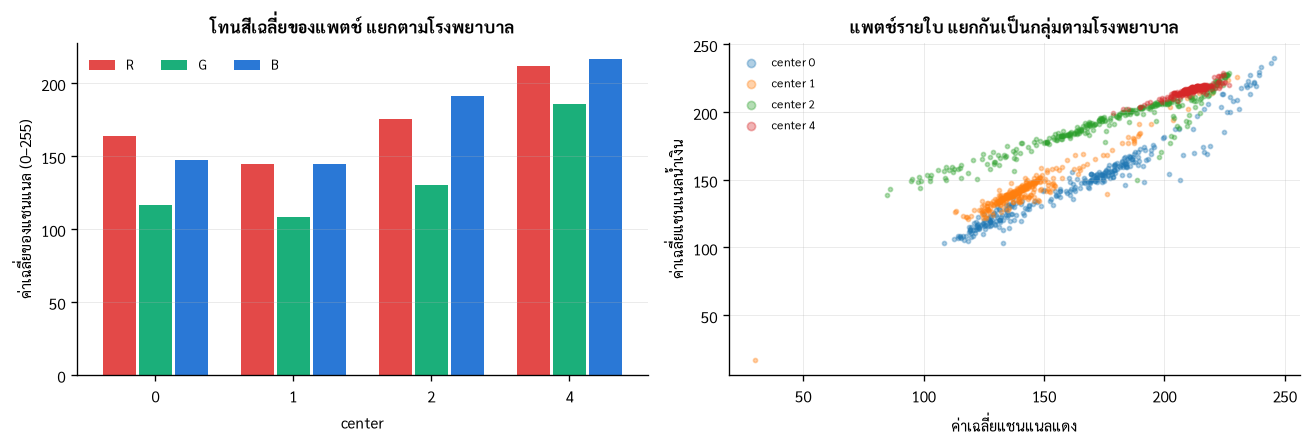

ช่วงห่างของค่าเฉลี่ยสีระหว่างโรงพยาบาลที่ต่างกันมากสุดกับน้อยสุด (ระดับสี 0–255):
R    67.300003
G    77.900002
B    71.800003


In [26]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))

width = 0.26
idx = np.arange(len(colour_by_center))
for offset, channel, col in zip((-width, 0, width), ("R", "G", "B"),
                                (C["red"], C["aqua"], C["blue"])):
    axes[0].bar(idx + offset, colour_by_center[channel], width=width - 0.02, color=col, label=channel)
axes[0].set_xticks(idx, colour_by_center.index.astype(str))
axes[0].set_xlabel("center")
axes[0].set_ylabel("ค่าเฉลี่ยของแชนแนล (0–255)")
axes[0].set_title("โทนสีเฉลี่ยของแพตช์ แยกตามโรงพยาบาล")
axes[0].legend(frameon=False, fontsize=8, ncol=3)
axes[0].grid(axis="x", visible=False)

for center, group in colour.groupby("center"):
    axes[1].scatter(group["R"], group["B"], s=6, alpha=0.35, label=f"center {center}")
axes[1].set_xlabel("ค่าเฉลี่ยแชนแนลแดง")
axes[1].set_ylabel("ค่าเฉลี่ยแชนแนลน้ำเงิน")
axes[1].set_title("แพตช์รายใบ แยกกันเป็นกลุ่มตามโรงพยาบาล")
axes[1].legend(frameon=False, fontsize=7, markerscale=2)

plt.tight_layout()
plt.show()

spread = colour_by_center[["R", "G", "B"]].max() - colour_by_center[["R", "G", "B"]].min()
print("ช่วงห่างของค่าเฉลี่ยสีระหว่างโรงพยาบาลที่ต่างกันมากสุดกับน้อยสุด (ระดับสี 0–255):")
print(spread.round(1).to_string())

---

# 4 · UCI Heart Disease · 4 โรงพยาบาล

ชุดเล็กที่สุดในบรรดาที่เก็บมา 920 แถว 38 KB แต่มี partition ธรรมชาติจริงคือ
เก็บจากสี่สถาบันคนละประเทศ: Cleveland Clinic · Hungarian Institute of Cardiology (บูดาเปสต์) ·
University Hospital Zurich/Basel (สวิตเซอร์แลนด์) · V.A. Medical Center Long Beach

เหตุผลที่เอามาเพิ่มทั้งที่เล็กมาก: **เวลาต่อรอบฝั่งเชนคงที่ราว 4.1 วินาทีไม่ว่าโมเดลจะใหญ่แค่ไหน
แต่เวลาเทรนกินเวลาส่วนใหญ่** ชุดนี้เทรนเสร็จในเสี้ยววินาที จึงเหมาะกับการรันหลายร้อยรอบ
เพื่อดูพฤติกรรมฝั่งเชนโดยไม่ต้องรอ GPU และมันยังให้จำนวนโหนดเป็น 4 ซึ่งเติมแกน scaling ได้

```bash
cd "poc/Finding Dataset/data" && mkdir -p heart && cd heart
for f in processed.cleveland.data processed.hungarian.data \
         processed.switzerland.data processed.va.data heart-disease.names; do
  curl -L -O "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/$f"
done
```

In [27]:
HEART = DATA / "heart"
require(HEART / "processed.cleveland.data", "ไฟล์ UCI Heart Disease")

HEART_COLS = ["age", "sex", "cp", "trestbps", "chol", "fbs", "restecg",
              "thalach", "exang", "oldpeak", "slope", "ca", "thal", "num"]
SITES = {"cleveland": "Cleveland", "hungarian": "Hungary",
         "switzerland": "Switzerland", "va": "Long Beach VA"}

parts = []
for key, name in SITES.items():
    df_site = pd.read_csv(HEART / f"processed.{key}.data", names=HEART_COLS, na_values="?")
    df_site["site"] = name
    parts.append(df_site)
heart = pd.concat(parts, ignore_index=True)
heart["disease"] = (heart["num"] > 0).astype(int)   # 0 = ปกติ, 1-4 = ป่วย ตามเอกสารของชุดข้อมูล

print(f"{len(heart)} แถว · {len(HEART_COLS) - 1} ฟีเจอร์ · {heart['site'].nunique()} สถาบัน")
heart.head(4)

920 แถว · 13 ฟีเจอร์ · 4 สถาบัน


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num,site,disease
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0,Cleveland,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2,Cleveland,1
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1,Cleveland,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0,Cleveland,0


In [28]:
heart_feats = [c for c in HEART_COLS if c != "num"]
by_site = (heart.groupby("site")
           .agg(แถว=("disease", "size"),
                ป่วย=("disease", "sum"),
                อายุเฉลี่ย=("age", "mean"))
           .assign(สัดส่วนป่วย=lambda d: (d["ป่วย"] / d["แถว"]).round(3),
                   อายุเฉลี่ย=lambda d: d["อายุเฉลี่ย"].round(1)))
by_site["ค่าว่าง_ต่อแถว"] = (heart.groupby("site")[heart_feats]
                             .apply(lambda g: g.isna().sum().sum() / len(g)).round(2))
by_site.sort_values("แถว", ascending=False)

,แถว,ป่วย,อายุเฉลี่ย,สัดส่วนป่วย,ค่าว่าง_ต่อแถว
site,,,,,
Cleveland,303,139,54.4,0.459,0.02
Hungary,294,106,47.8,0.361,2.66
Long Beach VA,200,149,59.4,0.745,3.49
Switzerland,123,115,55.3,0.935,2.22


ตัวเลขสัดส่วนป่วยคือจุดที่ชุดนี้มีค่ากับเป้าหมาย generalize:
**ความชุกของโรคต่างกันมากระหว่างสถาบัน** ซึ่งเป็น label shift ของจริงที่เกิดจากวิธีส่งต่อผู้ป่วย
โรงพยาบาลเฉพาะทางย่อมได้เคสหนักกว่าคลินิกทั่วไป โมเดลที่เทรนกับที่หนึ่งแล้วเอาไปใช้อีกที่หนึ่ง
จะเจอฐานความน่าจะเป็นคนละแบบทันที

อีกชั้นคือ **ฟีเจอร์ที่เก็บได้ไม่เท่ากัน** ดูคอลัมน์ค่าว่างต่อแถว — บางสถาบันไม่ได้วัดบางอย่างเลย
ซึ่งเป็นปัญหาที่เจอจริงในงาน federated ระหว่างโรงพยาบาล

In [29]:
missing_by_site = (heart.groupby("site")[heart_feats].apply(lambda g: g.isna().mean())
                   .round(3).T)
missing_by_site[(missing_by_site > 0).any(axis=1)]

site,Cleveland,Hungary,Long Beach VA,Switzerland
trestbps,0.000,0.003,0.280,0.016
chol,0.000,0.078,0.035,0.000
fbs,0.000,0.027,0.035,0.610
restecg,0.000,0.003,0.000,0.008
thalach,0.000,0.003,0.265,0.008
exang,0.000,0.003,0.265,0.008
oldpeak,0.000,0.000,0.280,0.049
slope,0.000,0.646,0.510,0.138
ca,0.013,0.990,0.990,0.959
thal,0.007,0.905,0.830,0.423


---

# 5 · แกนการ generalize ของแต่ละแขนง

เป้าหมายคือให้โมเดลที่ผ่าน swarm learning ใช้กับข้อมูลที่ไม่เคยเห็นได้ ซึ่งแปลว่า
**ต้องกัน silo ไว้ทดสอบ ไม่ใช่สุ่มแบ่ง train/test จากกองเดียวกัน** สามแขนงที่เก็บมามีแกนคนละแบบ
และมีเพียงแขนงเดียวที่มี protocol อย่างเป็นทางการมาให้แล้ว

In [30]:
axes = pd.DataFrame([
    {"แขนง": "cyber", "ชุดข้อมูล": "N-BaIoT", "แกนที่กันไว้ทดสอบได้": "อุปกรณ์ (leave-one-device-out)",
     "silo": 9, "protocol ทางการ": "ไม่มี ต้องกำหนดเอง",
     "สิ่งที่ทดสอบได้": "โมเดลใช้กับอุปกรณ์รุ่นที่ไม่เคยเห็นได้ไหม"},
    {"แขนง": "finance", "ชุดข้อมูล": "Elliptic", "แกนที่กันไว้ทดสอบได้": "เวลา (อดีต → อนาคต)",
     "silo": 49, "protocol ทางการ": "มี · Weber et al. ts 1-34 เทรน / 35-49 ทดสอบ",
     "สิ่งที่ทดสอบได้": "โมเดลยังใช้ได้ไหมเมื่อรูปแบบอาชญากรรมเปลี่ยน"},
    {"แขนง": "medical", "ชุดข้อมูล": "Camelyon17-WILDS", "แกนที่กันไว้ทดสอบได้": "โรงพยาบาล (leave-one-hospital-out)",
     "silo": 5, "protocol ทางการ": "มี · เทรน 0,3,4 · val 1 · ทดสอบ 2",
     "สิ่งที่ทดสอบได้": "โมเดลใช้กับโรงพยาบาลที่ย้อมสไลด์คนละแบบได้ไหม"},
    {"แขนง": "medical", "ชุดข้อมูล": "UCI Heart Disease", "แกนที่กันไว้ทดสอบได้": "สถาบัน (leave-one-site-out)",
     "silo": 4, "protocol ทางการ": "ไม่มี ต้องกำหนดเอง",
     "สิ่งที่ทดสอบได้": "โมเดลใช้กับประชากรผู้ป่วยคนละกลุ่มได้ไหม"},
])
axes

,แขนง,ชุดข้อมูล,แกนที่กันไว้ทดสอบได้,silo,protocol ทางการ,สิ่งที่ทดสอบได้
0,cyber,N-BaIoT,อุปกรณ์ (leave-one-device-out),9,ไม่มี ต้องกำหนดเอง,โมเดลใช้กับอุปกรณ์รุ่นที่ไม่เคยเห็นได้ไหม
1,finance,Elliptic,เวลา (อดีต → อนาคต),49,มี · Weber et al. ts 1-34 เทรน / 35-49 ทดสอบ,โมเดลยังใช้ได้ไหมเมื่อรูปแบบอาชญากรรมเปลี่ยน
2,medical,Camelyon17-WILDS,โรงพยาบาล (leave-one-hospital-out),5,"มี · เทรน 0,3,4 · val 1 · ทดสอบ 2",โมเดลใช้กับโรงพยาบาลที่ย้อมสไลด์คนละแบบได้ไหม
3,medical,UCI Heart Disease,สถาบัน (leave-one-site-out),4,ไม่มี ต้องกำหนดเอง,โมเดลใช้กับประชากรผู้ป่วยคนละกลุ่มได้ไหม


### วัดว่า silo ห่างกันแค่ไหน

ถ้า silo เหมือนกันหมด การกันหนึ่ง silo ไว้ทดสอบก็ไม่ต่างจากสุ่มแบ่ง และผลลัพธ์จะไม่บอกอะไรเรื่อง generalize
เซลล์ข้างล่างจึงวัดระยะห่างระหว่าง silo ด้วยตัวเลขเดียวกันทุกชุด เพื่อให้เทียบข้ามแขนงได้:

ทำ z-score ให้ทุกฟีเจอร์ก่อน แล้วหาค่าเฉลี่ยของแต่ละ silo จากนั้นวัด
**ค่าเฉลี่ยของ |ผลต่าง| ต่อฟีเจอร์ ระหว่าง silo คู่หนึ่ง หน่วยเป็นจำนวนเท่าของส่วนเบี่ยงเบนมาตรฐาน**
ตัวเลขนี้ไม่ขึ้นกับจำนวนฟีเจอร์ จึงเทียบข้ามชุดข้อมูลได้ตรง ๆ ยิ่งมากยิ่งแปลว่า silo ต่างกันมาก
และงาน generalize ยิ่งยาก

In [31]:
def silo_gap(frame: pd.DataFrame, feature_cols: list, silos) -> dict:
    """ระยะห่างเฉลี่ยต่อฟีเจอร์ระหว่าง silo หน่วยเป็นเท่าของ SD
    รับ silos เป็น array แยก ไม่ยัดเป็นคอลัมน์เข้า frame ที่กว้างอยู่แล้ว"""
    block = frame[feature_cols].astype(float)
    z = (block - block.mean()) / block.std(ddof=0).replace(0, np.nan)
    centroids = z.groupby(np.asarray(silos)).mean()
    silos = list(centroids.index)
    gaps = {}
    for i, a in enumerate(silos):
        for b in silos[i + 1:]:
            gaps[(a, b)] = float((centroids.loc[a] - centroids.loc[b]).abs().mean(skipna=True))
    worst = max(gaps, key=gaps.get)
    return {"silo": len(silos), "ห่างเฉลี่ย": round(float(np.mean(list(gaps.values()))), 3),
            "ห่างมากสุด": round(gaps[worst], 3), "คู่ที่ห่างสุด": f"{worst[0]} ↔ {worst[1]}"}


# cyber: สุ่ม benign อย่างเดียวจากทุกอุปกรณ์ เพื่อวัดความต่างของทราฟฟิกปกติล้วน ๆ
nb_parts, nb_silo = [], []
for device in per_device.index:
    part = pd.read_csv(NBAIOT / device / "benign_traffic.csv", nrows=2000)
    nb_parts.append(part)
    nb_silo.extend([device] * len(part))
nb_mix = pd.concat(nb_parts, ignore_index=True)
nb_cols = list(nb_mix.columns)
# เก็บ silo ไว้เป็น Series แยก ไม่ยัดกลับเข้า frame ที่มี 115 คอลัมน์
nb_silo = pd.Series(nb_silo, name="silo")

In [32]:
rows = []

rows.append({"แขนง": "cyber", "ชุดข้อมูล": "N-BaIoT (benign เท่านั้น)",
             "แบ่งตาม": "อุปกรณ์",
             **silo_gap(nb_mix, nb_cols, nb_silo.to_numpy())})

ell_silo = labelled["time_step"].map(step_groups).reindex(features.index)
keep = ell_silo.notna()
rows.append({"แขนง": "finance", "ชุดข้อมูล": "Elliptic (แบ่งตามช่วงเวลา)", "แบ่งตาม": "ช่วง time step",
             **silo_gap(features.loc[keep], feature_cols, ell_silo[keep].to_numpy())})

rows.append({"แขนง": "medical", "ชุดข้อมูล": "Camelyon17-WILDS (สีของแพตช์)", "แบ่งตาม": "โรงพยาบาล",
             **silo_gap(colour, ["R", "G", "B", "sd"], colour["center"].to_numpy())})

heart_numeric = heart[heart_feats].apply(pd.to_numeric, errors="coerce")
rows.append({"แขนง": "medical", "ชุดข้อมูล": "UCI Heart Disease", "แบ่งตาม": "สถาบัน",
             **silo_gap(heart_numeric, heart_feats, heart["site"].to_numpy())})

gap_table = pd.DataFrame(rows)
gap_table

,แขนง,ชุดข้อมูล,แบ่งตาม,silo,ห่างเฉลี่ย,ห่างมากสุด,คู่ที่ห่างสุด
0,cyber,N-BaIoT (benign เท่านั้น),อุปกรณ์,9,0.473,1.226,Danmini_Doorbell ↔ Philips_B120N10_Baby_Monitor
1,finance,Elliptic (แบ่งตามช่วงเวลา),ช่วง time step,5,0.189,0.305,silo1 ↔ silo5
2,medical,Camelyon17-WILDS (สีของแพตช์),โรงพยาบาล,4,0.965,1.759,1 ↔ 4
3,medical,UCI Heart Disease,สถาบัน,4,0.545,0.616,Cleveland ↔ Switzerland


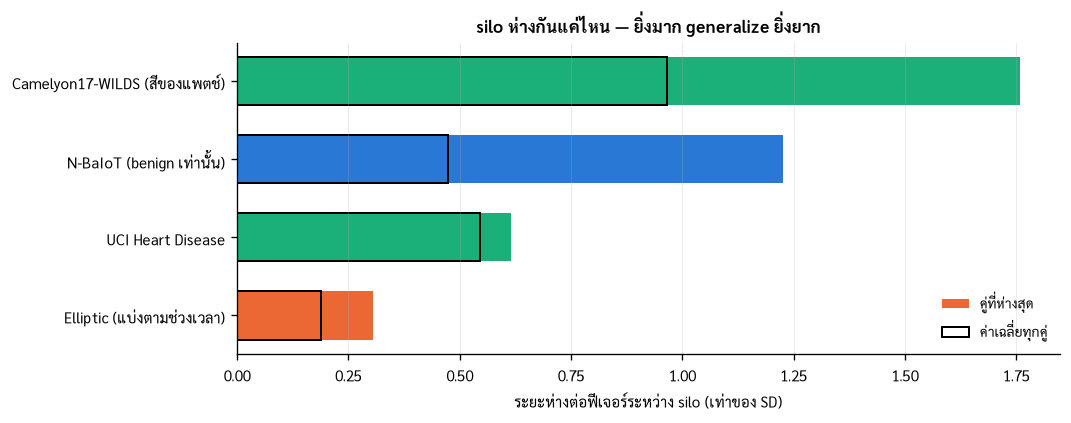

In [33]:
fig, ax = plt.subplots(figsize=(9, 3.6))
order = gap_table.sort_values("ห่างมากสุด")
colours = {"cyber": C["blue"], "finance": C["orange"], "medical": C["aqua"]}
ax.barh(order["ชุดข้อมูล"], order["ห่างมากสุด"],
        color=[colours[b] for b in order["แขนง"]], height=0.62, label="คู่ที่ห่างสุด")
ax.barh(order["ชุดข้อมูล"], order["ห่างเฉลี่ย"], color="#00000000",
        edgecolor="black", linewidth=1.2, height=0.62, label="ค่าเฉลี่ยทุกคู่")
ax.set_xlabel("ระยะห่างต่อฟีเจอร์ระหว่าง silo (เท่าของ SD)")
ax.set_title("silo ห่างกันแค่ไหน — ยิ่งมาก generalize ยิ่งยาก")
ax.legend(frameon=False, fontsize=8, loc="lower right")
ax.grid(axis="y", visible=False)
plt.tight_layout()
plt.show()

### ชุดที่พิจารณาแล้วไม่ได้เอามา

บันทึกไว้เพื่อไม่ต้องกลับไปค้นซ้ำ และเพื่อเขียนในรายงานได้ว่าเลือกมาอย่างไร

In [34]:
rejected = pd.DataFrame([
    {"ชุดข้อมูล": "CICIoT2023", "แขนง": "cyber", "silo ที่อ้าง": "105 อุปกรณ์",
     "เหตุผลที่ไม่เอา": "CSV เป็นฟีเจอร์ระดับ flow ไม่มีคอลัมน์ระบุอุปกรณ์ งานที่ใช้จึงแบ่ง client เอาเอง 10 ก้อน และลิงก์ดาวน์โหลดตรงคืนหน้า HTML"},
    {"ชุดข้อมูล": "Elliptic++", "แขนง": "finance", "silo ที่อ้าง": "ไม่มี",
     "เหตุผลที่ไม่เอา": "เพิ่ม wallet 822k แต่ยังแบ่งตาม time step อย่างเดียว ไม่ได้เพิ่มแกน silo"},
    {"ชุดข้อมูล": "CIC-IDS2017 / TON_IoT", "แขนง": "cyber", "silo ที่อ้าง": "ไม่มี",
     "เหตุผลที่ไม่เอา": "ไม่มี partition มาตรฐาน ต่างคนต่างแบ่ง เทียบข้ามงานไม่ได้"},
    {"ชุดข้อมูล": "FeTS 2022", "แขนง": "medical", "silo ที่อ้าง": "23 สถาบัน",
     "เหตุผลที่ไม่เอา": "silo เยอะที่สุดที่เจอและเป็น federated challenge จริง แต่ต้องลงทะเบียนและเป็น MRI 1,251 เคส หนักเกินเครื่องนี้ — เก็บไว้เป็นตัวเลือกถ้าย้ายไปเครื่องแรงกว่า"},
    {"ชุดข้อมูล": "Fed-ISIC2019", "แขนง": "medical", "silo ที่อ้าง": "6 ศูนย์",
     "เหตุผลที่ไม่เอา": "อยู่ใน FLamby โหลดได้จริงราว 9 GB เป็นตัวเลือกสำรองถ้าต้องการ silo เพิ่มในแขนงการแพทย์"},
])
rejected

,ชุดข้อมูล,แขนง,silo ที่อ้าง,เหตุผลที่ไม่เอา
0,CICIoT2023,cyber,105 อุปกรณ์,CSV เป็นฟีเจอร์ระดับ flow ไม่มีคอลัมน์ระบุอุปก...
1,Elliptic++,finance,ไม่มี,เพิ่ม wallet 822k แต่ยังแบ่งตาม time step อย่า...
2,CIC-IDS2017 / TON_IoT,cyber,ไม่มี,ไม่มี partition มาตรฐาน ต่างคนต่างแบ่ง เทียบข้...
3,FeTS 2022,medical,23 สถาบัน,silo เยอะที่สุดที่เจอและเป็น federated challen...
4,Fed-ISIC2019,medical,6 ศูนย์,อยู่ใน FLamby โหลดได้จริงราว 9 GB เป็นตัวเลือก...


---

# 6 · สรุปเทียบกัน

ตารางนี้ให้คะแนนตามเกณฑ์ที่ตั้งไว้ตอนต้น โดยอ้างตัวเลขที่วัดได้ข้างบน

In [35]:
verdict = pd.DataFrame([
    {"ชุดข้อมูล": "N-BaIoT", "partition ธรรมชาติ": "มี · 9 อุปกรณ์",
     "ขนาดที่ต้องโหลด": "~1 GB zip", "baseline": "Meidan et al. 2018",
     "เหตุผลเรื่องเชน": "ปานกลาง", "รันบนเครื่องนี้": "ได้ ถ้าสุ่มตัวอย่างต่อโหนด"},
    {"ชุดข้อมูล": "Elliptic", "partition ธรรมชาติ": "ไม่มี · ต้องสังเคราะห์",
     "ขนาดที่ต้องโหลด": "~700 MB", "baseline": "Weber et al. 2019",
     "เหตุผลเรื่องเชน": "แข็งที่สุด", "รันบนเครื่องนี้": "ได้สบาย"},
    {"ชุดข้อมูล": "Camelyon17-WILDS", "partition ธรรมชาติ": "มี · 5 โรงพยาบาล",
     "ขนาดที่ต้องโหลด": "~10 GB", "baseline": "WILDS (Koh et al. 2021)",
     "เหตุผลเรื่องเชน": "ปานกลาง", "รันบนเครื่องนี้": "ได้ ถ้าสุ่มตัวอย่างต่อโหนด"},
    {"ชุดข้อมูล": "UCI Heart Disease", "partition ธรรมชาติ": "มี · 4 สถาบัน",
     "ขนาดที่ต้องโหลด": "38 KB", "baseline": "ใช้กันแพร่หลาย แต่ไม่มี split มาตรฐาน",
     "เหตุผลเรื่องเชน": "ปานกลาง", "รันบนเครื่องนี้": "ได้ทันที"},
])
verdict

,ชุดข้อมูล,partition ธรรมชาติ,ขนาดที่ต้องโหลด,baseline,เหตุผลเรื่องเชน,รันบนเครื่องนี้
0,N-BaIoT,มี · 9 อุปกรณ์,~1 GB zip,Meidan et al. 2018,ปานกลาง,ได้ ถ้าสุ่มตัวอย่างต่อโหนด
1,Elliptic,ไม่มี · ต้องสังเคราะห์,~700 MB,Weber et al. 2019,แข็งที่สุด,ได้สบาย
2,Camelyon17-WILDS,มี · 5 โรงพยาบาล,~10 GB,WILDS (Koh et al. 2021),ปานกลาง,ได้ ถ้าสุ่มตัวอย่างต่อโหนด
3,UCI Heart Disease,มี · 4 สถาบัน,38 KB,ใช้กันแพร่หลาย แต่ไม่มี split มาตรฐาน,ปานกลาง,ได้ทันที


### อ่านจากตัวเลขที่วัดมา

- **N-BaIoT ตอบโจทย์ข้อที่ติดอยู่** คือเรื่องไม่มี partition มาตรฐาน เพราะมันไม่ต้องมี
  การแบ่งตามอุปกรณ์มากับข้อมูลเอง ใครรันก็ได้ชุดเดียวกัน เทียบข้ามงานได้จริง
  และความเอียงของมันอธิบายได้ด้วยเหตุผลทางกายภาพ ไม่ใช่ผลของการสุ่ม:
  สองอุปกรณ์ขาดคลาส Mirai เพราะไม่เคยติดเชื้อจริง รันกี่ครั้งก็ได้รูปเดิม

- **Elliptic ให้เรื่องเล่าที่ดีที่สุดแต่ต้องยอมรับจุดอ่อน** ถ้าใช้ชุดนี้ ต้องเขียนในรายงานตรง ๆ
  ว่า partition เป็นการสังเคราะห์ พร้อมเหตุผลว่าเลือกแบ่งแบบไหนเพราะอะไร
  ซึ่งก็คือข้อจำกัดเดียวกับที่ทำให้ CIC-IDS2017 เทียบข้าม paper ไม่ได้

- **ถ้าอยากได้ทั้งสองอย่าง** ใช้ N-BaIoT เป็นชุดหลักสำหรับตัวเลข scaling
  แล้วใช้ Elliptic เป็นกรณีศึกษาที่สองสำหรับข้อโต้แย้งเรื่องการตรวจสอบย้อนหลัง
  โครงบนเชนรองรับอยู่แล้ว เพราะช่องถูกตั้งเป็นหนึ่งช่องต่อคู่ dataset-model
  สองชุดจึงอยู่คนละเชน รอบไม่ปนกัน